# Module 5 — Improved LSTM Volatility Forecasting

**QuantRisk AI**

This module loads the feature-engineered dataset produced by Module 3 and forecasts **future 20-trading-day realized volatility**.

### Improvements in this version
- No unnecessary package installation.
- Chronological train/validation/test split with a true 20-session target purge.
- Imputer and scaler are fitted **only on training data**.
- Validation/test sequences may use **historical observations immediately before the split**, which is realistic at prediction time.
- The target for every evaluation observation remains strictly in its own future period, preventing target leakage.
- Test data is used only for final evaluation.


## 1. Imports and configuration

In [1]:
import os
import pickle
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

RANDOM_STATE = 42
HORIZON = 20
LOOKBACK = 60
BATCH_SIZE = 256
EPOCHS = 30
LEARNING_RATE = 1e-3
PATIENCE = 5

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.14.1+cpu
Device: cpu


In [4]:
CANDIDATE_PATHS = [
    "../backend/data/feature_engineered_dataset.csv",
    "backend/data/feature_engineered_dataset.csv"
]
DATA_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Module 3 output not found. Save the final engineered dataframe as "
        "data/feature_engineered_dataset.csv before running Module 5."
    )

df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df = df.sort_values(["Stock", "Date"]).reset_index(drop=True)
print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())

Loaded: ../backend/data/feature_engineered_dataset.csv
Shape: (70764, 37)


,Date,Stock,Open,High,Low,Close,Volume,NIFTY_Close,VIX_Close,Daily_Return,...,Volume_MA20,Volume_Ratio,Volume_Change,Price_Range,High_Low_Pct,Gap_Pct,NIFTY_Return,Beta_Causal,Future_Volatility_20D,High_Risk
0,2020-01-02,ADANIENT,205.943023,211.091595,205.447967,209.111374,2991937,12282.200195,11.49,NaN,...,NaN,NaN,NaN,5.643628,0.026989,NaN,NaN,NaN,0.018001,0.0
1,2020-01-03,ADANIENT,208.170764,210.250002,203.764775,206.240051,2512421,12226.650391,12.70,-0.013731,...,NaN,NaN,-0.160269,6.485228,0.031445,-0.004498,-0.004523,NaN,0.017769,0.0
2,2020-01-06,ADANIENT,205.695488,205.695488,195.794382,197.576584,4353179,11993.049805,14.78,-0.042007,...,NaN,NaN,0.732663,9.901107,0.050113,-0.002640,-0.019106,NaN,0.017129,0.0
3,2020-01-07,ADANIENT,198.566702,203.665766,198.566702,202.032089,2966120,12052.950195,14.61,0.022551,...,NaN,NaN,-0.318631,5.099064,0.025239,0.005011,0.004995,NaN,0.017030,0.0
4,2020-01-08,ADANIENT,199.012223,201.537008,192.626013,199.507278,5762654,12025.349609,15.64,-0.012497,...,NaN,NaN,0.942826,8.910995,0.044665,-0.014947,-0.002290,NaN,0.018982,0.0


## 3. Verify Module 3 features

In [5]:
LSTM_FEATURES = [
    "Daily_Return",
    "Rolling_Volatility_20D",
    "Rolling_Volatility_60D",
    "Price_MA20_Ratio",
    "Price_MA50_Ratio",
    "Momentum_20D",
    "RSI_14",
    "MACD",
    "MACD_Histogram",
    "ATR_14",
    "Beta_Causal",
    "Volatility_Ratio",
    "Volume_Ratio",
    "Volume_Change",
    "High_Low_Pct",
    "Gap_Pct"
]
missing = [c for c in LSTM_FEATURES if c not in df.columns]
if missing:
    raise ValueError(f"Missing Module 3 features: {missing}")
print(f"Verified {len(LSTM_FEATURES)} Module 3 features.")

Verified 16 Module 3 features.


## 4. Create future 20-trading-day realized volatility target

For observation **t**, the target is the sample standard deviation of returns from **t+1 through t+20** for the same stock. The current-day return is excluded.

In [6]:
def future_volatility(series, horizon=20):
    values = series.to_numpy(dtype=float)
    out = np.full(len(values), np.nan)
    for i in range(len(values) - horizon):
        window = values[i + 1:i + 1 + horizon]
        if np.isfinite(window).all():
            out[i] = np.std(window, ddof=1)
    return pd.Series(out, index=series.index)

df["Future_Volatility_20D"] = (
    df.groupby("Stock", group_keys=False)["Daily_Return"]
      .apply(lambda s: future_volatility(s, HORIZON))
)
print("Valid targets:", df["Future_Volatility_20D"].notna().sum())
display(df["Future_Volatility_20D"].describe().round(6))

Valid targets: 69784


count    69784.000000
mean         0.017809
std          0.009641
min          0.003449
25%          0.012062
50%          0.015666
75%          0.020581
max          0.152320
Name: Future_Volatility_20D, dtype: float64

## 5. Chronological split and true trading-session purge

- Train: 2020–2023
- Validation: 2024
- Test: 2025

A 20-market-session purge is applied at the end of train and validation so labels cannot use returns from a later evaluation period.

In [7]:
TRAIN_END = pd.Timestamp("2023-12-31")
VAL_END = pd.Timestamp("2024-12-31")
TEST_END = pd.Timestamp("2025-12-31")

trading_dates = np.sort(df["Date"].dropna().unique())
date_to_idx = pd.Series(np.arange(len(trading_dates)), index=trading_dates)
df["Market_Day_Index"] = df["Date"].map(date_to_idx)

train_end_idx = int(date_to_idx.loc[trading_dates[trading_dates <= TRAIN_END][-1]])
val_end_idx = int(date_to_idx.loc[trading_dates[trading_dates <= VAL_END][-1]])

train_mask = (
    (df["Date"] <= TRAIN_END) &
    df["Future_Volatility_20D"].notna() &
    (df["Market_Day_Index"] <= train_end_idx - HORIZON)
)
val_mask = (
    (df["Date"] > TRAIN_END) &
    (df["Date"] <= VAL_END) &
    df["Future_Volatility_20D"].notna() &
    (df["Market_Day_Index"] <= val_end_idx - HORIZON)
)
test_mask = (
    (df["Date"] > VAL_END) &
    (df["Date"] <= TEST_END) &
    df["Future_Volatility_20D"].notna()
)

print("Train rows:", int(train_mask.sum()))
print("Validation rows:", int(val_mask.sum()))
print("Test rows:", int(test_mask.sum()))

Train rows: 45725
Validation rows: 10976
Test rows: 11123


## 6. Train-only preprocessing

In [8]:
X_train_raw = df.loc[train_mask, LSTM_FEATURES].copy()
y_train_raw = df.loc[train_mask, "Future_Volatility_20D"].to_numpy(dtype=np.float32)

X_val_raw = df.loc[val_mask, LSTM_FEATURES].copy()
y_val_raw = df.loc[val_mask, "Future_Volatility_20D"].to_numpy(dtype=np.float32)

X_test_raw = df.loc[test_mask, LSTM_FEATURES].copy()
y_test_raw = df.loc[test_mask, "Future_Volatility_20D"].to_numpy(dtype=np.float32)

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

# Fit ONLY on training observations.
imputer.fit(X_train_raw)
scaler.fit(imputer.transform(X_train_raw))

# Transform every observation using the training-fitted objects.
X_all_imp = imputer.transform(df[LSTM_FEATURES])
X_all_scaled = scaler.transform(X_all_imp).astype(np.float32)

print("Train:", X_train_raw.shape)
print("Validation:", X_val_raw.shape)
print("Test:", X_test_raw.shape)
print("Full transformed feature matrix:", X_all_scaled.shape)

Train: (45725, 16)
Validation: (10976, 16)
Test: (11123, 16)
Full transformed feature matrix: (70764, 16)


## 7. Improved sequence construction

Each prediction uses the current observation plus the previous 59 observations for the same stock.

**Important:** For a validation/test prediction, historical observations immediately before the split are allowed because they were already known at that prediction date. Only the **target** is restricted to the evaluation period.

This avoids unnecessarily discarding the first 59 validation/test observations while keeping the evaluation leakage-safe.

In [9]:
def make_sequences_with_history(df, target_mask, X_all_scaled, lookback=60):
    target_indices = np.flatnonzero(target_mask.to_numpy())
    X_list, y_list, meta = [], [], []

    # Global dataframe positions are already sorted by Stock and Date.
    stock_positions = {
        stock: g.index.to_numpy()
        for stock, g in df.groupby("Stock", sort=False)
    }

    for idx in target_indices:
        stock = df.at[idx, "Stock"]
        positions = stock_positions[stock]
        loc = np.searchsorted(positions, idx)

        if loc < lookback - 1:
            continue

        window_positions = positions[loc - lookback + 1:loc + 1]
        window = X_all_scaled[window_positions]

        if window.shape != (lookback, len(LSTM_FEATURES)):
            continue
        if not np.isfinite(window).all():
            continue

        X_list.append(window)
        y_list.append(float(df.at[idx, "Future_Volatility_20D"]))
        meta.append((df.at[idx, "Date"], stock, idx))

    X = np.asarray(X_list, dtype=np.float32)
    y = np.asarray(y_list, dtype=np.float32)
    meta = pd.DataFrame(meta, columns=["Date", "Stock", "Global_Index"])
    return X, y, meta

Xtr, ytr, meta_tr = make_sequences_with_history(df, train_mask, X_all_scaled, LOOKBACK)
Xva, yva, meta_va = make_sequences_with_history(df, val_mask, X_all_scaled, LOOKBACK)
Xte, yte, meta_te = make_sequences_with_history(df, test_mask, X_all_scaled, LOOKBACK)

print("Train sequences:", Xtr.shape, ytr.shape)
print("Validation sequences:", Xva.shape, yva.shape)
print("Test sequences:", Xte.shape, yte.shape)

Train sequences: (42834, 60, 16) (42834,)
Validation sequences: (10976, 60, 16) (10976,)
Test sequences: (11123, 60, 16) (11123,)


## 8. Sequence and leakage sanity checks

In [10]:
assert Xtr.ndim == 3 and Xtr.shape[1:] == (LOOKBACK, len(LSTM_FEATURES))
assert Xva.ndim == 3 and Xva.shape[1:] == (LOOKBACK, len(LSTM_FEATURES))
assert Xte.ndim == 3 and Xte.shape[1:] == (LOOKBACK, len(LSTM_FEATURES))
assert np.isfinite(Xtr).all() and np.isfinite(Xva).all() and np.isfinite(Xte).all()
assert np.isfinite(ytr).all() and np.isfinite(yva).all() and np.isfinite(yte).all()

# Target dates must remain inside their intended periods.
assert meta_tr["Date"].max() <= TRAIN_END
assert meta_va["Date"].min() > TRAIN_END and meta_va["Date"].max() <= VAL_END
assert meta_te["Date"].min() > VAL_END and meta_te["Date"].max() <= TEST_END

print("Sequence checks passed.")
print("First train target:", meta_tr["Date"].min())
print("Validation target range:", meta_va["Date"].min(), "to", meta_va["Date"].max())
print("Test target range:", meta_te["Date"].min(), "to", meta_te["Date"].max())

Sequence checks passed.
First train target: 2020-03-27 00:00:00
Validation target range: 2024-01-02 00:00:00 to 2024-12-02 00:00:00
Test target range: 2025-01-02 00:00:00 to 2025-12-02 00:00:00


## 9. PyTorch DataLoaders

In [11]:
train_loader = DataLoader(
    TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr).unsqueeze(1)),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(Xva), torch.from_numpy(yva).unsqueeze(1)),
    batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(Xte), torch.from_numpy(yte).unsqueeze(1)),
    batch_size=BATCH_SIZE, shuffle=False
)
print("Batches:", len(train_loader), len(val_loader), len(test_loader))

Batches: 168 43 44


## 10. LSTM architecture

In [12]:
class VolatilityLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        output, _ = self.lstm(x)
        last_hidden = output[:, -1, :]
        return self.fc(self.dropout(last_hidden))

model = VolatilityLSTM(len(LSTM_FEATURES)).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(model)

VolatilityLSTM(
  (lstm): LSTM(16, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## 11. Train with early stopping

In [13]:
best_val_loss = np.inf
best_state = None
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_sum = 0.0
    train_n = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_sum += loss.item() * len(xb)
        train_n += len(xb)

    model.eval()
    val_sum = 0.0
    val_n = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            val_sum += loss.item() * len(xb)
            val_n += len(xb)

    train_loss = train_sum / train_n
    val_loss = val_sum / val_n
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")

    if val_loss < best_val_loss - 1e-7:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping.")
            break

model.load_state_dict(best_state)
print("Best validation MSE:", best_val_loss)

Epoch 01/30 | Train MSE: 0.000284 | Val MSE: 0.000049
Epoch 02/30 | Train MSE: 0.000069 | Val MSE: 0.000049
Epoch 03/30 | Train MSE: 0.000055 | Val MSE: 0.000047
Epoch 04/30 | Train MSE: 0.000049 | Val MSE: 0.000045
Epoch 05/30 | Train MSE: 0.000044 | Val MSE: 0.000046
Epoch 06/30 | Train MSE: 0.000041 | Val MSE: 0.000046
Epoch 07/30 | Train MSE: 0.000039 | Val MSE: 0.000046
Epoch 08/30 | Train MSE: 0.000037 | Val MSE: 0.000044
Epoch 09/30 | Train MSE: 0.000036 | Val MSE: 0.000045
Epoch 10/30 | Train MSE: 0.000034 | Val MSE: 0.000046
Epoch 11/30 | Train MSE: 0.000034 | Val MSE: 0.000046
Epoch 12/30 | Train MSE: 0.000033 | Val MSE: 0.000047
Epoch 13/30 | Train MSE: 0.000031 | Val MSE: 0.000045
Early stopping.
Best validation MSE: 4.435178683807669e-05


## 12. Training and validation loss

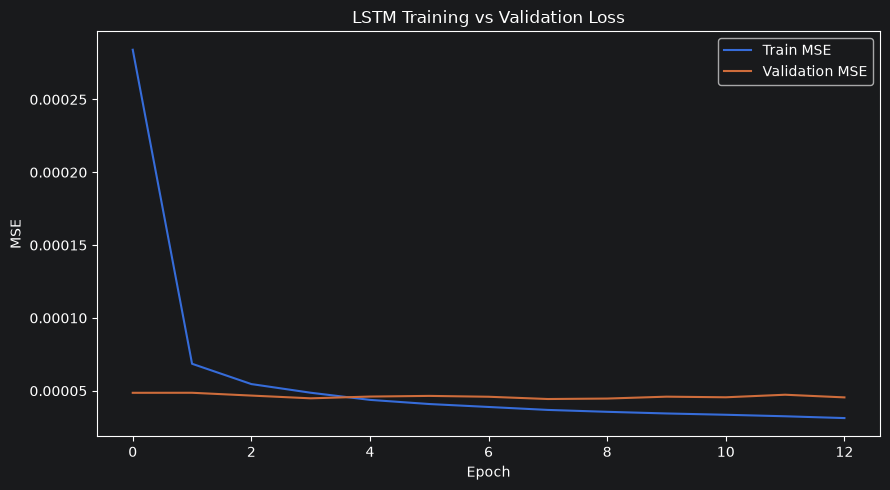

In [14]:
plt.figure(figsize=(9, 5))
plt.plot(train_losses, label="Train MSE")
plt.plot(val_losses, label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Generate validation and test predictions

In [15]:
def predict_loader(model, loader):
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            preds.append(model(xb).cpu().numpy().ravel())
            actuals.append(yb.numpy().ravel())
    return np.concatenate(preds), np.concatenate(actuals)

yva_pred, yva_true = predict_loader(model, val_loader)
yte_pred, yte_true = predict_loader(model, test_loader)

# Volatility cannot be negative. Clip only the model output, not the true target.
yva_pred = np.clip(yva_pred, 0, None)
yte_pred = np.clip(yte_pred, 0, None)

print("Validation predictions:", len(yva_pred))
print("Test predictions:", len(yte_pred))

Validation predictions: 10976
Test predictions: 11123


## 14. Regression evaluation

In [16]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Correlation": np.corrcoef(y_true, y_pred)[0, 1]
    }

metrics = pd.DataFrame([
    {"Split": "Validation", **regression_metrics(yva_true, yva_pred)},
    {"Split": "Test 2025", **regression_metrics(yte_true, yte_pred)}
])

display(metrics.round(6))

,Split,MAE,RMSE,R2,Correlation
0,Validation,0.004443,0.006660,0.090115,0.332828
1,Test 2025,0.003592,0.004837,0.307081,0.584989


## 15. Actual vs predicted volatility

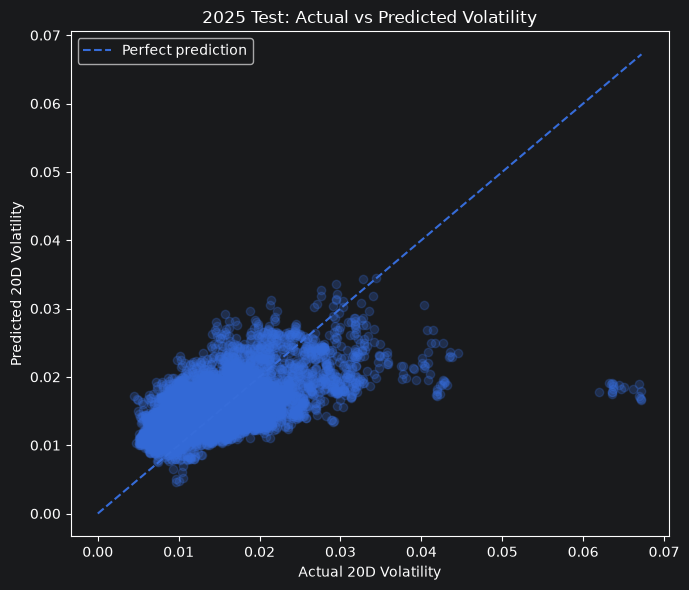

In [17]:
plt.figure(figsize=(7, 6))
plt.scatter(yte_true, yte_pred, alpha=0.25)
lims = [0, max(yte_true.max(), yte_pred.max())]
plt.plot(lims, lims, linestyle="--", label="Perfect prediction")
plt.xlabel("Actual 20D Volatility")
plt.ylabel("Predicted 20D Volatility")
plt.title("2025 Test: Actual vs Predicted Volatility")
plt.legend()
plt.tight_layout()
plt.show()

## 16. Chronological test forecast

In [18]:
test_predictions = meta_te.copy()
test_predictions["Actual_Volatility"] = yte_true
test_predictions["Predicted_Volatility"] = yte_pred
test_predictions["Absolute_Error"] = np.abs(
    test_predictions["Actual_Volatility"] - test_predictions["Predicted_Volatility"]
)

test_predictions = test_predictions.sort_values(["Date", "Stock"]).reset_index(drop=True)
display(test_predictions.head(20))

,Date,Stock,Global_Index,Actual_Volatility,Predicted_Volatility,Absolute_Error
0,2025-01-02,ADANIENT,1223,0.028617,0.023869,0.004748
1,2025-01-02,ADANIPORTS,2693,0.021135,0.021332,0.000196
2,2025-01-02,APOLLOHOSP,4163,0.015752,0.014070,0.001682
3,2025-01-02,ASIANPAINT,5633,0.013223,0.013711,0.000488
4,2025-01-02,AXISBANK,7103,0.016710,0.015081,0.001630
5,2025-01-02,BAJAJ-AUTO,8573,0.012035,0.015119,0.003084
6,2025-01-02,BAJAJFINSV,10043,0.016898,0.016711,0.000187
7,2025-01-02,BAJFINANCE,11513,0.018531,0.016567,0.001964
8,2025-01-02,BEL,12983,0.027301,0.018424,0.008877
9,2025-01-02,BHARTIARTL,14453,0.010823,0.014733,0.003910


## 17. High-risk classification using a training-only threshold

In [19]:
risk_threshold = float(np.quantile(ytr, 0.75))
actual_high = (yte_true >= risk_threshold).astype(int)
pred_high = (yte_pred >= risk_threshold).astype(int)

tp = int(((actual_high == 1) & (pred_high == 1)).sum())
tn = int(((actual_high == 0) & (pred_high == 0)).sum())
fp = int(((actual_high == 0) & (pred_high == 1)).sum())
fn = int(((actual_high == 1) & (pred_high == 0)).sum())

precision = tp / (tp + fp) if tp + fp else 0.0
recall = tp / (tp + fn) if tp + fn else 0.0
f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
balanced_accuracy = 0.5 * (tn / (tn + fp) + tp / (tp + fn))
accuracy = (tp + tn) / len(actual_high)

print(f"Training 75th-percentile risk threshold: {risk_threshold:.6f} ({risk_threshold:.2%})")
print(f"Accuracy: {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")
print("Confusion Matrix:")
print(np.array([[tn, fp], [fn, tp]]))

Training 75th-percentile risk threshold: 0.021286 (2.13%)
Accuracy: 0.9114
Balanced Accuracy: 0.6419
Precision: 0.5148
Recall: 0.3131
F1: 0.3893
Confusion Matrix:
[[9824  296]
 [ 689  314]]


## 18. Largest forecasting errors

In [20]:
display(
    test_predictions.nlargest(15, "Absolute_Error")
    [["Date", "Stock", "Actual_Volatility", "Predicted_Volatility", "Absolute_Error"]]
    .round(6)
)

C:\Users\Nalavade\AppData\Local\Temp\ipykernel_16640\3949633846.py:4: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(6)


,Date,Stock,Actual_Volatility,Predicted_Volatility,Absolute_Error
2179,2025-03-06,INDUSINDBK,0.067131,0.016624,0.050507
2130,2025-03-05,INDUSINDBK,0.067205,0.016773,0.050432
2081,2025-03-04,INDUSINDBK,0.066977,0.016942,0.050034
2032,2025-03-03,INDUSINDBK,0.066874,0.017243,0.049632
2228,2025-03-07,INDUSINDBK,0.067106,0.017977,0.049129
2277,2025-03-10,INDUSINDBK,0.066882,0.018935,0.047947
1983,2025-02-28,INDUSINDBK,0.066140,0.018221,0.047918
1885,2025-02-25,INDUSINDBK,0.065048,0.018447,0.046601
1934,2025-02-27,INDUSINDBK,0.064724,0.018255,0.046469
1395,2025-02-11,INDUSINDBK,0.063606,0.017438,0.046168


## 19. Save LSTM artifacts

In [21]:
MODEL_DIR = "../backend/models"

os.makedirs(MODEL_DIR, exist_ok=True)

torch.save(
    model.state_dict(),
    os.path.join(MODEL_DIR, "lstm_volatility_model.pt")
)

preprocessing = {
    "features": LSTM_FEATURES,
    "lookback": LOOKBACK,
    "horizon": HORIZON,
    "risk_threshold": risk_threshold,
    "imputer": imputer,
    "scaler": scaler
}

with open(
    os.path.join(MODEL_DIR, "lstm_preprocessing.pkl"),
    "wb"
) as f:
    pickle.dump(preprocessing, f)

test_predictions.to_csv(
    os.path.join(MODEL_DIR, "lstm_test_predictions.csv"),
    index=False
)

print("Saved:")
print("- ../backend/models/lstm_volatility_model.pt")
print("- ../backend/models/lstm_preprocessing.pkl")
print("- ../backend/models/lstm_test_predictions.csv")



Saved:
- models/lstm_volatility_model.pt
- models/lstm_preprocessing.pkl
- models/lstm_test_predictions.csv
